<style>
.note {padding: 12px 16px; border-left: 5px solid #2563eb; background: #eff6ff; margin: 10px 0;}
.warn {padding: 12px 16px; border-left: 5px solid #d97706; background: #fffbeb; margin: 10px 0;}
.fix  {padding: 12px 16px; border-left: 5px solid #dc2626; background: #fef2f2; margin: 10px 0;}
.exam {padding: 12px 16px; border-left: 5px solid #059669; background: #ecfdf5; margin: 10px 0;}
table {font-size: 95%;}
</style>

# 02 — Z-Test Hypothesis Testing

### Tests for means and proportions using the standard normal distribution

**Level:** beginner → advanced  
**Style:** short explanations, worked examples, formulas, runnable code, revision material

## What you will be able to do

- recognise when a z-test is justified
- solve left-, right-, and two-tailed one-sample z-tests
- calculate critical values, p-values, and z confidence intervals
- spot and correct two arithmetic issues in the lecture examples

## Resource coverage

- Transcript lines 672–1656: test-family overview, city-height example, z table, p-value, bulb-warranty example
- Handwritten Z-test resource: pages 1–2 develop the two-tailed height example; pages 3–4 develop the left-tailed bulb example

<div class="note"><b>How to study this notebook:</b> Read once without memorising. Then rerun the code, solve each checkpoint without looking, and finish with the cheat sheet.</div>


## 1. What a z-test asks

A one-sample z-test compares a sample mean $\bar x$ with a claimed population mean $\mu_0$ when the population standard deviation $\sigma$ is known.

$$Z=\frac{\bar X-\mu_0}{\sigma/\sqrt n}$$

Where:

- $\bar X-\mu_0$ = observed difference from the null claim.
- $\sigma/\sqrt n$ = standard error of the sample mean.
- $Z$ = number of standard errors between the sample mean and $\mu_0$.

The lecture uses two heuristics: known $\sigma$ and $n\ge30$. The precise rule is better:

- **Known $\sigma$** is the defining condition for the classical mean z-test.
- The population should be normal, or $n$ should be large enough for the sampling distribution of $\bar X$ to be approximately normal.
- If $\sigma$ is unknown and replaced by $s$, use a t-test—even when $n$ is large. For large degrees of freedom, t and z become nearly identical.


## 2. Tail direction and critical values

| Alternative | Tail | Reject at $\alpha=0.05$ |
|---|---|---|
| $\mu\ne\mu_0$ | two | $|z|>1.96$ |
| $\mu>\mu_0$ | right | $z>1.645$ |
| $\mu<\mu_0$ | left | $z<-1.645$ |

Critical-value formulas:

- Right-tailed: $z_{1-\alpha}$
- Left-tailed: $z_{\alpha}$
- Two-tailed: $\pm z_{1-\alpha/2}$

P-value formulas:

- Right: $P(Z\ge z_{obs})=1-\Phi(z_{obs})$
- Left: $P(Z\le z_{obs})=\Phi(z_{obs})$
- Two-sided: $2[1-\Phi(|z_{obs}|)]$


In [1]:
import math
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=4, suppress=True)


In [2]:
def one_sample_z_test(xbar, mu0, sigma, n, alternative='two-sided'):
    z = (xbar - mu0) / (sigma / math.sqrt(n))
    if alternative == 'two-sided':
        p = 2 * stats.norm.sf(abs(z))
    elif alternative == 'greater':
        p = stats.norm.sf(z)
    elif alternative == 'less':
        p = stats.norm.cdf(z)
    else:
        raise ValueError("alternative must be 'two-sided', 'greater', or 'less'")
    return z, p

print(one_sample_z_test(169.5, 168, 3.9, 36, 'two-sided'))


(2.3076923076923075, np.float64(0.021016256227518675))


## 3. Worked example 1: city heights

Given:

- Historical population mean: $\mu_0=168$ cm
- Known population SD: $\sigma=3.9$ cm
- Sample size: $n=36$
- Sample mean: $\bar x=169.5$ cm
- Confidence level: 95%, so $\alpha=0.05$
- Research claim: mean is **different**, so use a two-tailed test

Hypotheses:

$$H_0:\mu=168 \qquad H_a:\mu\ne168$$

Standard error:

$$SE=\frac{3.9}{\sqrt{36}}=0.65$$

Statistic:

$$z=\frac{169.5-168}{0.65}=2.3077$$

Two-tailed p-value:

$$p=2P(Z\ge2.3077)\approx0.0210$$

Decision: $0.0210<0.05$, so reject $H_0$.

Contextual conclusion: the sample provides statistically significant evidence that the city’s mean height differs from 168 cm. The positive estimate suggests it is higher, but the original two-sided question is “different”.

<div class="fix"><b>Resource correction:</b> the lecture alternates between 2.31 and 2.39. Using the supplied values gives z = 2.3077, approximately 2.31.</div>


In [3]:
# Critical-value route and p-value route give the same decision.
z_obs, p_value = one_sample_z_test(169.5, 168, 3.9, 36)
z_critical = stats.norm.ppf(1 - 0.05/2)

print(f"Observed z:       {z_obs:.4f}")
print(f"Critical values: {-z_critical:.4f}, +{z_critical:.4f}")
print(f"Two-sided p:      {p_value:.6f}")
print("Decision: reject H0" if abs(z_obs) > z_critical else "Decision: fail to reject H0")


Observed z:       2.3077
Critical values: -1.9600, +1.9600
Two-sided p:      0.021016
Decision: reject H0


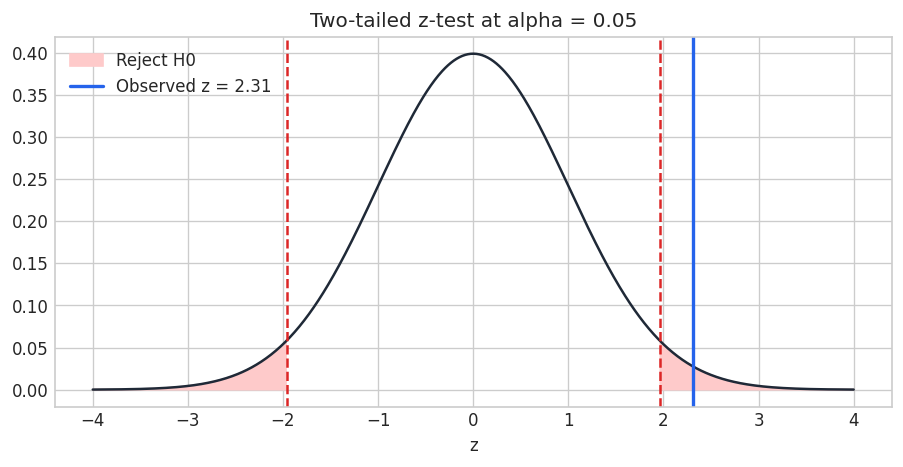

In [4]:
# Visual decision boundary for the city-height example.
grid = np.linspace(-4, 4, 800)
density = stats.norm.pdf(grid)
critical = stats.norm.ppf(0.975)

plt.figure(figsize=(9, 4))
plt.plot(grid, density, color='#1f2937')
plt.fill_between(grid, density, where=(grid <= -critical) | (grid >= critical), color='#fecaca', label='Reject H0')
plt.axvline(z_obs, color='#2563eb', linewidth=2, label=f'Observed z = {z_obs:.2f}')
plt.axvline(-critical, color='#dc2626', linestyle='--')
plt.axvline(critical, color='#dc2626', linestyle='--')
plt.title('Two-tailed z-test at alpha = 0.05')
plt.xlabel('z')
plt.legend()
plt.show()


## 4. Worked example 2: bulb warranty

Given:

- Claimed mean warranty: $\mu_0=5$ years
- Known SD: $\sigma=0.50$ years
- $n=40$, $\bar x=4.8$ years
- Worker claims bulbs fail in **less** than 5 years
- $\alpha=0.02$

Hypotheses:

$$H_0:\mu=5 \quad\text{(or }\mu\ge5\text{)} \qquad H_a:\mu<5$$

Test statistic:

$$z=\frac{4.8-5}{0.50/\sqrt{40}}=-2.5298$$

Because this is left-tailed:

$$p=P(Z\le-2.5298)=0.005706$$

Decision: $0.005706<0.02$, so **reject $H_0$**.

Conclusion: there is significant evidence, at the 2% level, that the mean warranty is below five years.

<div class="fix"><b>Resource correction:</b> page 3/4 of the handwritten sheet and the transcript shift the decimal from 0.00570 to 0.0570 and therefore give the wrong decision. The correct p-value is 0.00570.</div>


In [5]:
z_bulb, p_bulb = one_sample_z_test(4.8, 5, 0.50, 40, 'less')
critical_bulb = stats.norm.ppf(0.02)
print(f"z = {z_bulb:.4f}")
print(f"p = {p_bulb:.6f}")
print(f"left-tail critical z = {critical_bulb:.4f}")
print("Reject H0" if p_bulb < 0.02 else "Fail to reject H0")


z = -2.5298
p = 0.005706
left-tail critical z = -2.0537
Reject H0


## 5. Confidence interval connection

For known $\sigma$, a $(1-\alpha)100\%$ z confidence interval for $\mu$ is:

$$\bar x\pm z_{1-\alpha/2}\frac{\sigma}{\sqrt n}$$

For a two-sided test at level $\alpha$:

- reject $H_0:\mu=\mu_0$ exactly when the matching confidence interval excludes $\mu_0$;
- fail to reject when the interval includes $\mu_0$.

City interval:

$$169.5\pm1.96(0.65)=(168.226,170.774)$$

Because 168 is outside, this matches the rejection decision.


## 6. Z-tests beyond one mean

### Two independent means, both population SDs known

$$z=\frac{(\bar x_1-\bar x_2)-\Delta_0}{\sqrt{\sigma_1^2/n_1+\sigma_2^2/n_2}}$$

### One population proportion

For $H_0:p=p_0$:

$$z=\frac{\hat p-p_0}{\sqrt{p_0(1-p_0)/n}}$$

Check that expected successes $np_0$ and failures $n(1-p_0)$ are sufficiently large. Exact binomial methods are safer for small counts.

### Two proportions

When testing $H_0:p_1=p_2$, the classical score z-test uses a pooled proportion in its null standard error. Confidence intervals for $p_1-p_2$ usually use an unpooled standard error.


## 7. Assumptions and failure modes

- Observations should be independent.
- Sampling should be random or the design should justify generalisation.
- The sampling distribution of the statistic should be approximately normal.
- For the mean z-test, $\sigma$ must genuinely be known—not merely replaced by $s$ and renamed.
- Outliers can strongly affect mean-based tests.
- A significant result does not rescue biased data collection.

<div class="exam"><b>Exam move:</b> state the hypotheses, tail, assumptions, statistic, p-value, decision, and contextual conclusion. Showing only “p &lt; 0.05” leaves easy marks on the table.</div>


# End-of-topic cheat sheet

| Need | Formula / rule |
|---|---|
| Mean z statistic | $z=(\bar x-\mu_0)/(\sigma/\sqrt n)$ |
| Standard error | $SE=\sigma/\sqrt n$ |
| Two-tailed p | $2\Phi(-|z|)$ |
| Right-tailed p | $1-\Phi(z)$ |
| Left-tailed p | $\Phi(z)$ |
| 95% two-sided critical z | $\pm1.96$ |
| 95% CI | $\bar x\pm1.96\sigma/\sqrt n$ |
| Main condition | known population $\sigma$ plus normal/large-sample justification |
| Decision | reject if p $\le\alpha$ |

**Sign check:** positive z means $\bar x>\mu_0$; negative z means $\bar x<\mu_0$.


# Revision questions and answers

**Q1. What does z = 2.4 mean?**

<details><summary>Answer</summary>

The sample estimate is 2.4 null standard errors above the null value.

</details>

---

**Q2. What is the defining distinction between a one-sample mean z-test and t-test?**

<details><summary>Answer</summary>

The z-test treats population SD $\sigma$ as known; the t-test estimates it with sample SD $s$.

</details>

---

**Q3. What makes the city-height test two-tailed?**

<details><summary>Answer</summary>

The alternative asks whether the mean is different, $\mu\ne168$, allowing either direction.

</details>

---

**Q4. What is the correct p-value for the bulb example?**

<details><summary>Answer</summary>

Approximately 0.005706 for the left-tailed test.

</details>

---

**Q5. At alpha = 0.02, what is the bulb decision?**

<details><summary>Answer</summary>

Reject $H_0$ because 0.005706 < 0.02.

</details>

---

**Q6. When do the critical-value and p-value methods disagree?**

<details><summary>Answer</summary>

They do not disagree when the same test, tail, alpha, and calculations are used.

</details>

---

**Q7. Can n >= 30 alone justify a z-test?**

<details><summary>Answer</summary>

No. It may justify a normal approximation, but the classical mean z-test also requires known $\sigma$.

</details>

---

**Q8. What interval corresponds to a two-sided 5% test?**

<details><summary>Answer</summary>

A 95% confidence interval built with the same model and standard error.

</details>
